In [3]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import (roc_auc_score, average_precision_score, 
                             f1_score, precision_score, recall_score, 
                             confusion_matrix, ConfusionMatrixDisplay, 
                             PrecisionRecallDisplay)
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

# Wczytanie i podział 
df = pd.read_csv("train_cleaned.csv")
df_sorted = df.sort_values("TransactionID").reset_index(drop=True)

n = len(df_sorted)
n_train, n_valid = int(n * 0.60), int(n * 0.80)

X_train = df_sorted.iloc[:n_train].drop(columns=["isFraud", "TransactionID"])
y_train = df_sorted.iloc[:n_train]["isFraud"]

X_valid = df_sorted.iloc[n_train:n_valid].drop(columns=["isFraud", "TransactionID"])
y_valid = df_sorted.iloc[n_train:n_valid]["isFraud"]

X_test = df_sorted.iloc[n_valid:].drop(columns=["isFraud", "TransactionID"])
y_test = df_sorted.iloc[n_valid:]["isFraud"]

def display_metrics_table(model_name, y_train, y_train_proba, y_valid, y_valid_proba, threshold=0.5):
    
    y_train_pred = (y_train_proba >= threshold).astype(int)
    train_metrics = {
        "ROC-AUC": roc_auc_score(y_train, y_train_proba),
        "PR-AUC": average_precision_score(y_train, y_train_proba),
        "F1-Score": f1_score(y_train, y_train_pred, zero_division=0),
        "Precision": precision_score(y_train, y_train_pred, zero_division=0),
        "Recall": recall_score(y_train, y_train_pred, zero_division=0)
    }
    y_valid_pred = (y_valid_proba >= threshold).astype(int)
    valid_metrics = {
        "ROC-AUC": roc_auc_score(y_valid, y_valid_proba),
        "PR-AUC": average_precision_score(y_valid, y_valid_proba),
        "F1-Score": f1_score(y_valid, y_valid_pred, zero_division=0),
        "Precision": precision_score(y_valid, y_valid_pred, zero_division=0),
        "Recall": recall_score(y_valid, y_valid_pred, zero_division=0)
    }
    df_metrics = pd.DataFrame({"Train": train_metrics, "Valid": valid_metrics}).round(4)
    print(model_name)
    display(df_metrics)
    print("\n")
   

In [ ]:
# drzewo baseline ze zbalansowanymi wagami klas
dt_model = DecisionTreeClassifier(max_depth=5, class_weight='balanced', random_state=123)
dt_model.fit(X_train, y_train)

train_proba_dt = dt_model.predict_proba(X_train)[:, 1]
valid_proba_dt = dt_model.predict_proba(X_valid)[:, 1]

display_metrics_table("Drzewo Baseline", y_train, train_proba_dt, y_valid, valid_proba_dt)

Drzewo Baseline


,Train,Valid
ROC-AUC,0.8172,0.8086
PR-AUC,0.2755,0.3189
F1-Score,0.2029,0.2402
Precision,0.1172,0.1437
Recall,0.7559,0.7328


In [ ]:
# ekperymenty- tuning drzewa
param_grid = {
    'max_depth': [3, 5, 7, 10],
    'min_samples_leaf': [10, 50, 100],
    'max_features': [None, 'sqrt', 'log2']
}

#  gridSearch z walidacją dla szeregów czasowych (zapobiega wyciekom)
tscv = TimeSeriesSplit(n_splits=3)
grid = GridSearchCV(DecisionTreeClassifier(class_weight='balanced', random_state=123), 
                    param_grid, scoring='roc_auc', cv=tscv)
grid.fit(X_train, y_train)


results_df = pd.DataFrame(grid.cv_results_)
table_to_report = results_df[['param_max_depth', 'param_min_samples_leaf', 'param_max_features', 'mean_test_score']]
table_to_report.columns = ['Max Depth', 'Min Samples Leaf', 'Max Features', 'Mean ROC-AUC']

print("Tabela wyników eksperymentu (Tuning drzewa - Top 10):")
display(table_to_report.sort_values(by='Mean ROC-AUC', ascending=False).head(10))

best_dt = grid.best_estimator_
print(f"\nNajlepsze drzewo: {grid.best_params_}\n")

train_proba_best_dt = best_dt.predict_proba(X_train)[:, 1]
valid_proba_best_dt = best_dt.predict_proba(X_valid)[:, 1]

display_metrics_table("Drzewo Optymalne", y_train, train_proba_best_dt, y_valid, valid_proba_best_dt)

Tabela wyników eksperymentu (Tuning drzewa - Top 10):


,Max Depth,Min Samples Leaf,Max Features,Mean ROC-AUC
35,10,100,log2,0.811016
34,10,50,log2,0.808188
22,7,50,sqrt,0.805166
23,7,100,sqrt,0.803883
19,7,50,None,0.801784
32,10,100,sqrt,0.801652
20,7,100,None,0.800575
26,7,100,log2,0.796535
21,7,10,sqrt,0.796408
31,10,50,sqrt,0.795564



Najlepsze drzewo: {'max_depth': 10, 'max_features': 'log2', 'min_samples_leaf': 100}

Drzewo Optymalne


,Train,Valid
ROC-AUC,0.8403,0.8348
PR-AUC,0.3448,0.3610
F1-Score,0.2243,0.2631
Precision,0.1326,0.1624
Recall,0.7275,0.6923


In [ ]:
# obliczenie wagi klasy dla niezbalansowanych danych
scale_weight = float((y_train == 0).sum() / (y_train == 1).sum())

model = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='auc',
    scale_pos_weight=scale_weight,
    random_state=123,
    max_depth=5,
    learning_rate=0.05,
    n_estimators=1000,
    early_stopping_rounds=50
)

model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_valid, y_valid)],
    verbose=100
)

[0]	validation_0-auc:0.81714	validation_1-auc:0.80831
[100]	validation_0-auc:0.90663	validation_1-auc:0.89463
[200]	validation_0-auc:0.92647	validation_1-auc:0.90447
[300]	validation_0-auc:0.93812	validation_1-auc:0.90857
[400]	validation_0-auc:0.94698	validation_1-auc:0.91053
[500]	validation_0-auc:0.95413	validation_1-auc:0.91191
[544]	validation_0-auc:0.95658	validation_1-auc:0.91165


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",50
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fr

In [ ]:
train_probs_xgb = model.predict_proba(X_train, iteration_range=(0, model.best_iteration + 1))[:, 1]
valid_probs_xgb = model.predict_proba(X_valid, iteration_range=(0, model.best_iteration + 1))[:, 1]

display_metrics_table("XGBoost", y_train, train_probs_xgb, y_valid, valid_probs_xgb)

XGBoost


,Train,Valid
ROC-AUC,0.9538,0.9120
PR-AUC,0.7118,0.5640
F1-Score,0.3974,0.3997
Precision,0.2599,0.2754
Recall,0.8443,0.7283


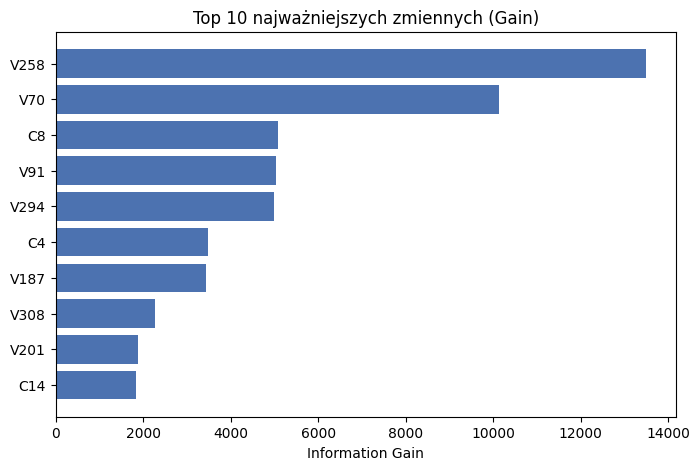

In [ ]:
#  zmienne, ktore mają największy wpływ na decyzje modelu
importance = model.get_booster().get_score(importance_type='gain')
df_imp = pd.DataFrame({'Feature': importance.keys(), 'Gain': importance.values()}).sort_values('Gain', ascending=True).tail(10)

plt.figure(figsize=(8, 5))
plt.barh(df_imp['Feature'], df_imp['Gain'], color='#4c72b0')
plt.title("Top 10 najważniejszych zmiennych (Gain)")
plt.xlabel("Information Gain")
plt.show()

In [ ]:
# testowanie różnych progów odcięcia na zbiorze walidacyjnym
valid_probs_xgb = model.predict_proba(X_valid, iteration_range=(0, model.best_iteration + 1))[:, 1]
thresholds = [0.5, 0.6, 0.7, 0.8, 0.85, 0.9, 0.95]

results = []
for thr in thresholds:
    pred = (valid_probs_xgb >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_valid, pred).ravel()
    
    prec = precision_score(y_valid, pred, zero_division=0)
    rec = recall_score(y_valid, pred, zero_division=0)
    f1 = f1_score(y_valid, pred, zero_division=0)
    
    results.append({
        "Próg": thr, 
        "TP": tp, 
        "FN": fn, 
        "FP": fp, 
        "Precision": round(prec, 4), 
        "Recall": round(rec, 4), 
        "F1-Score": round(f1, 4)
    })

threshold_analysis_df = pd.DataFrame(results)
print("Analiza progów odcięcia")
display(threshold_analysis_df)

Analiza progów odcięcia


,Próg,TP,FN,FP,Precision,Recall,F1-Score
0,0.50,3358,1253,8834,0.2754,0.7283,0.3997
1,0.60,2994,1617,5149,0.3677,0.6493,0.4695
2,0.70,2587,2024,2699,0.4894,0.5610,0.5228
3,0.80,2153,2458,1206,0.6410,0.4669,0.5403
4,0.85,1912,2699,704,0.7309,0.4147,0.5291
5,0.90,1660,2951,385,0.8117,0.3600,0.4988
6,0.95,1348,3263,180,0.8822,0.2923,0.4392


In [ ]:
final_results = pd.DataFrame({
    "Model": ["Drzewo Decyzyjne (Optymalne)", "XGBoost"],
    "ROC-AUC (Test)": [
        roc_auc_score(y_test, best_dt.predict_proba(X_test)[:, 1]),
        roc_auc_score(y_test, model.predict_proba(X_test, iteration_range=(0, model.best_iteration + 1))[:, 1])
    ]
})

print("Tabela sumaryczna - wybór najlepszego modelu:")
display(final_results)

Tabela sumaryczna - wybór najlepszego modelu:


,Model,ROC-AUC (Test)
0,Drzewo Decyzyjne (Optymalne),0.802976
1,XGBoost,0.875059


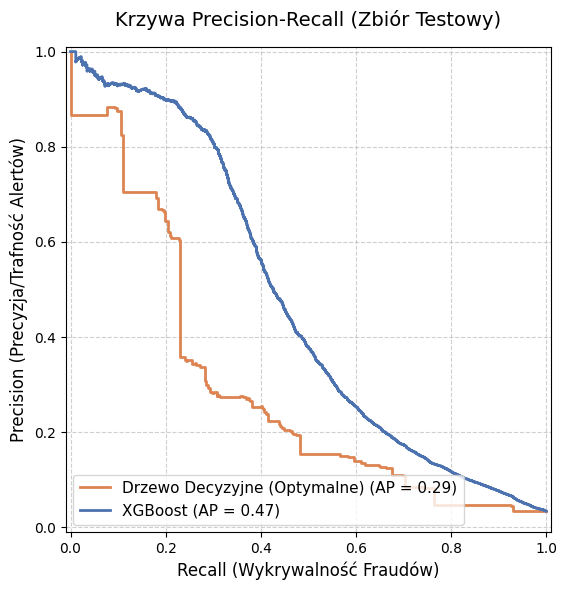

In [ ]:
from sklearn.metrics import PrecisionRecallDisplay
import matplotlib.pyplot as plt

# krzywa Precision-Recall 
plt.style.use('default')
fig, ax = plt.subplots(figsize=(10, 6))


PrecisionRecallDisplay.from_estimator(
    best_dt, X_test, y_test, 
    name="Drzewo Decyzyjne (Optymalne)", 
    ax=ax, 
    color='#dd8452',
    linewidth=2
)


y_prob_xgb = model.predict_proba(X_test, iteration_range=(0, model.best_iteration + 1))[:, 1]

PrecisionRecallDisplay.from_predictions(
    y_test, y_prob_xgb, 
    name="XGBoost", 
    ax=ax, 
    color='#4c72b0',
    linewidth=2
)

plt.title("Krzywa Precision-Recall (Zbiór Testowy)", fontsize=14, pad=15)
plt.xlabel("Recall (Wykrywalność Fraudów)", fontsize=12)
plt.ylabel("Precision (Precyzja/Trafność Alertów)", fontsize=12)
plt.legend(loc="lower left", fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

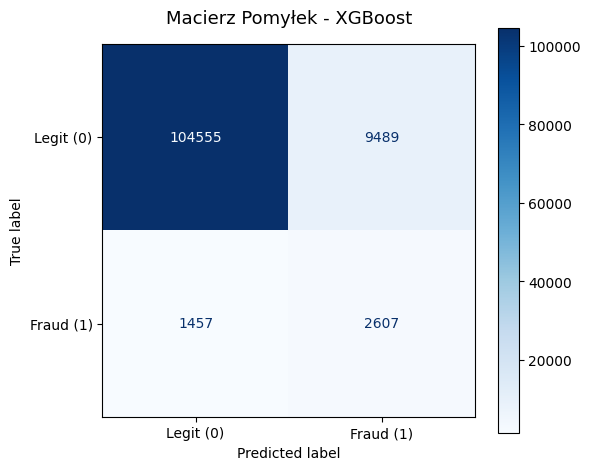

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

#macierz pomylek
wybrany_prog = 0.5

y_pred_test_xgb = (y_prob_xgb >= wybrany_prog).astype(int)


cm = confusion_matrix(y_test, y_pred_test_xgb)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm, 
    display_labels=['Legit (0)', 'Fraud (1)']
)

disp.plot(ax=ax, cmap='Blues', values_format='d')

plt.title(f"Macierz Pomyłek - XGBoost", fontsize=13, pad=15)
plt.tight_layout()
plt.show()